# Customer Churn Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stat

## Overview of the Dataset

In [12]:
data=pd.read_csv('/Users/kamyasindhu/Downloads/Customer-Churn-Records.csv')

In [13]:
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

In [15]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [19]:
print(data.duplicated().sum())

0


In [20]:
print(data.isna().sum())

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [21]:
data.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='str')

## Drawing Insights

In [85]:
churn_rate=data['Exited'].value_counts(normalize=True)*100

In [87]:
churn_rate

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64

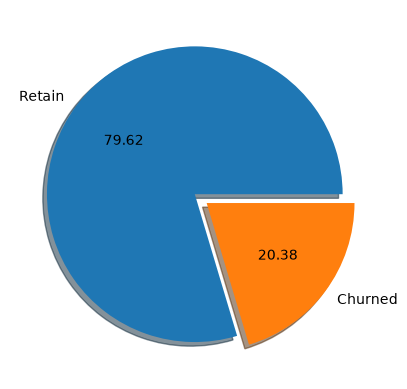

In [103]:
plt.pie(churn_rate.values,labels=['Retain','Churned'],autopct='%.2f',shadow=True,explode=[0,0.1])
plt.show()

In [25]:
Card_Type=data['Card Type'].value_counts(normalize=True)*100

In [30]:
Card_Type

Card Type
DIAMOND     25.07
GOLD        25.02
SILVER      24.96
PLATINUM    24.95
Name: proportion, dtype: float64

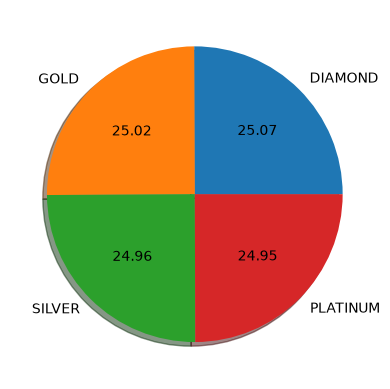

In [36]:
plt.pie(Card_Type.values,labels=Card_Type.index,autopct='%.2f',shadow=True)
plt.show()

In [41]:
data.groupby('Card Type')['Point Earned'].mean().round(2)

Card Type
DIAMOND     605.98
GOLD        607.24
PLATINUM    608.84
SILVER      604.00
Name: Point Earned, dtype: float64

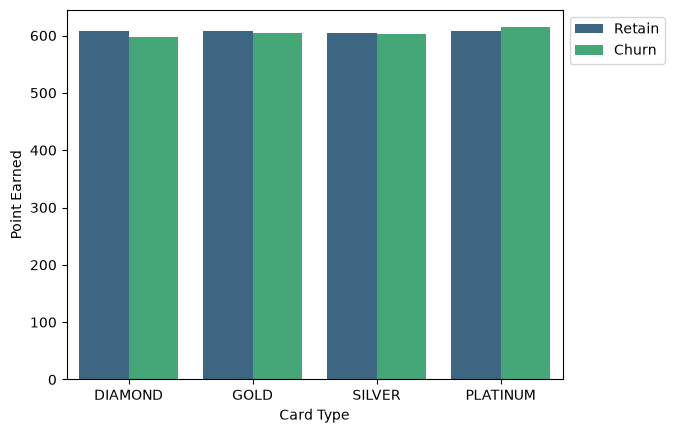

In [256]:
a=sns.barplot(data=data,x='Card Type',y='Point Earned',hue='Exited',palette='viridis',errorbar=None)
handles,legend=a.get_legend_handles_labels()
plt.legend(bbox_to_anchor=[1,1],handles=handles,labels=['Retain','Churn'])
plt.show()

In [83]:
churn=data[data['Exited']==1].groupby('Tenure').size()

In [88]:
churn

Tenure
0      95
1     232
2     201
3     213
4     203
5     209
6     196
7     177
8     197
9     214
10    101
dtype: int64

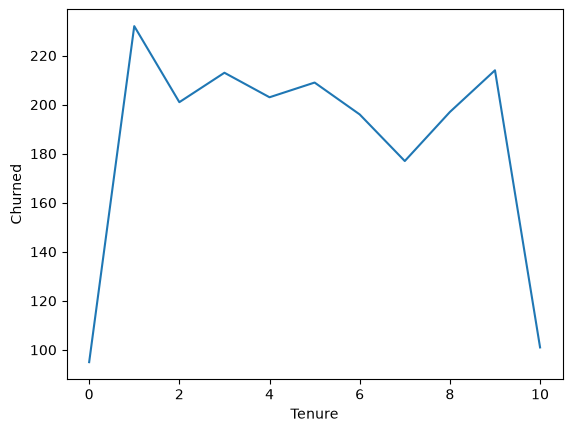

In [96]:
plt.plot(churn.index,churn.values)
plt.xlabel('Tenure')
plt.ylabel('Churned')
plt.show()

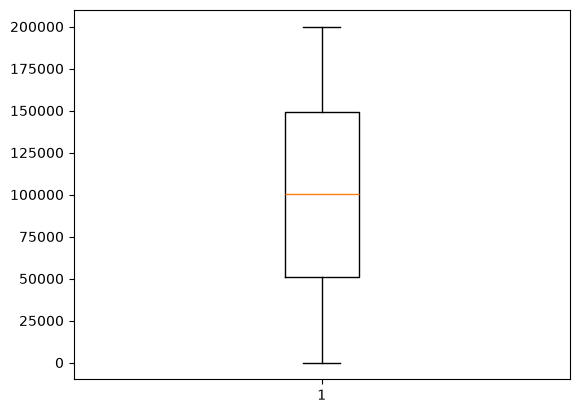

In [110]:
plt.boxplot(data['EstimatedSalary'])
plt.show()

In [116]:
active=data.groupby(['Gender','IsActiveMember']).size().reset_index(name='Number')

In [120]:
active

,Gender,IsActiveMember,Number
0,Female,0,2259
1,Female,1,2284
2,Male,0,2590
3,Male,1,2867


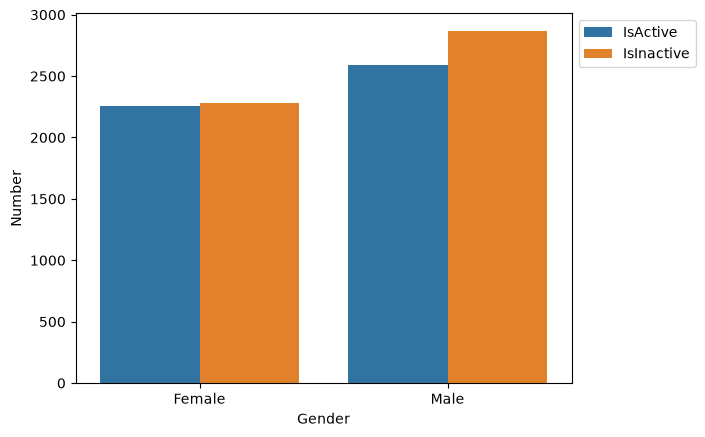

In [119]:
b=sns.barplot(data=active,x='Gender',y='Number',hue='IsActiveMember')
handles,legend=b.get_legend_handles_labels()
plt.legend(bbox_to_anchor=[1,1],handles=handles,labels=['IsActive','IsInactive'])
plt.show()

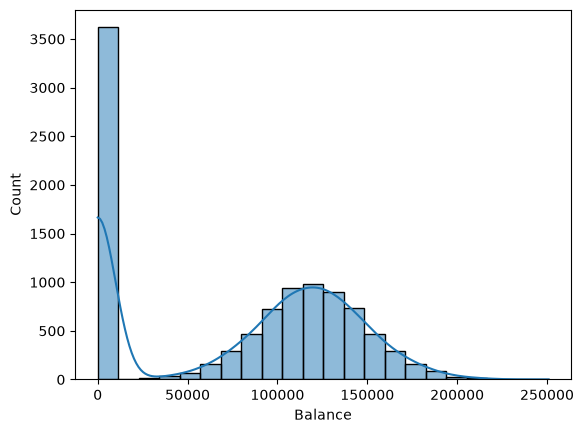

In [277]:
sns.histplot(data=data,x=data['Balance'],kde=True)
plt.show()

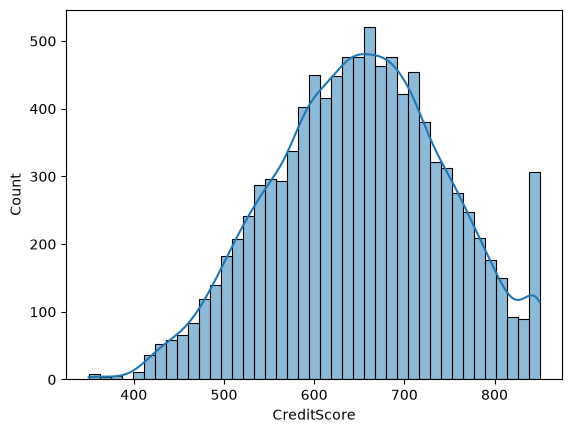

In [276]:
sns.histplot(data=data,x=data['CreditScore'],kde=True)
plt.show()

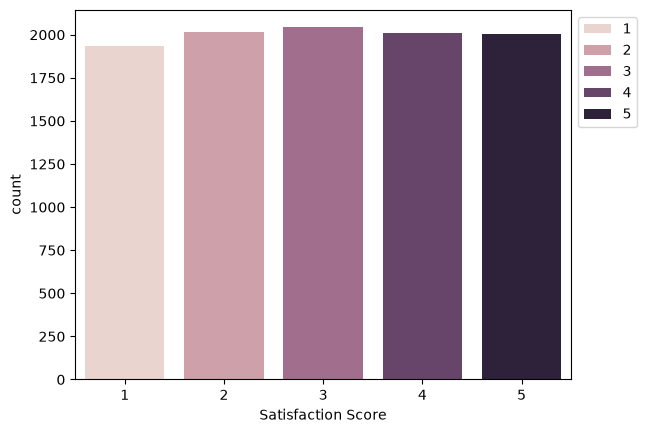

In [130]:
sns.countplot(data=data,x='Satisfaction Score',hue='Satisfaction Score')
plt.legend(bbox_to_anchor=[1,1])
plt.show()

In [134]:
data['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [164]:
satisfaction=data['Satisfaction Score'].value_counts().sort_index()

In [166]:
satisfaction=pd.DataFrame(satisfaction)

In [171]:
satisfaction

,count
Satisfaction Score,
1,1932
2,2014
3,2042
4,2008
5,2004


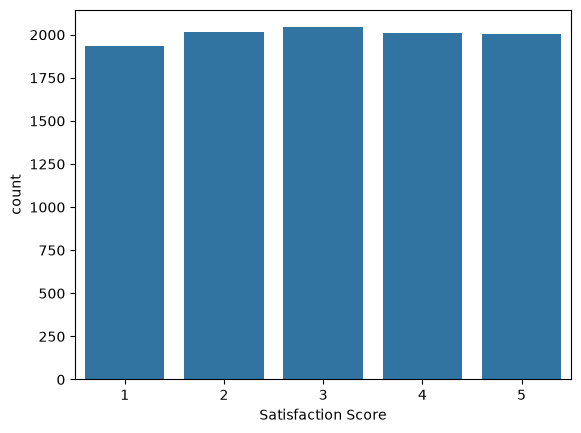

In [184]:
sns.barplot(data=satisfaction,x='Satisfaction Score',y='count')
plt.show()

In [275]:
(data[(data['Complain']==1)&(data['HasCrCard']==1)].size/data[data['HasCrCard']==1].size)*100
print(x,'% of customers have complain and hold a credit card.')

20.882852292020374 % of customers have complain and hold a credit card.


In [273]:
x=(data[(data['Complain']==1)&(data['HasCrCard']==0)].size/data[data['HasCrCard']==0].size)*100
print(x,'% of customers have complain but,do not hold a credit card.')

20.882852292020374 % of customers have complain but,do not hold a credit card.


In [197]:
no_of_prod=data['NumOfProducts'].value_counts()

In [201]:
no_of_prod=pd.DataFrame(no_of_prod)

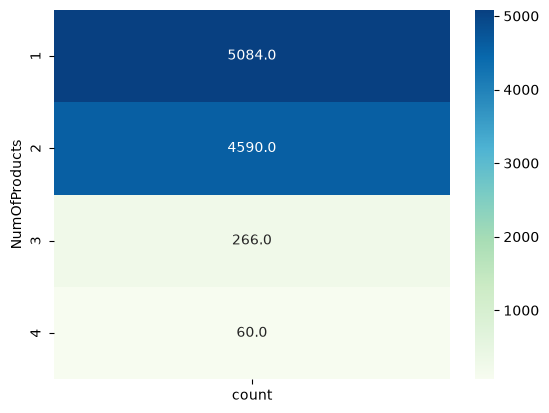

In [215]:
sns.heatmap(data=no_of_prod,cmap='GnBu',annot=True,fmt='.1f')
plt.show()

In [227]:
pt_grp=data.groupby('Card Type')['EstimatedSalary'].mean()

In [246]:
pt_grp=pd.DataFrame(pt_grp)

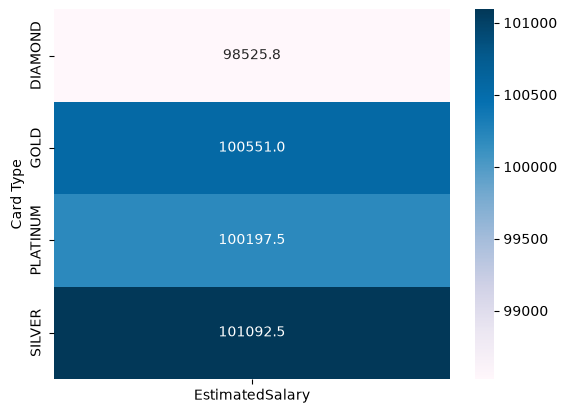

In [252]:
sns.heatmap(pt_grp,annot=True,fmt='.1f',cmap='PuBu')
plt.show()

In [232]:
data.groupby(['Geography','Card Type']).size()

Geography  Card Type
France     DIAMOND      1230
           GOLD         1235
           PLATINUM     1264
           SILVER       1285
Germany    DIAMOND       648
           GOLD          653
           PLATINUM      608
           SILVER        600
Spain      DIAMOND       629
           GOLD          614
           PLATINUM      623
           SILVER        611
dtype: int64

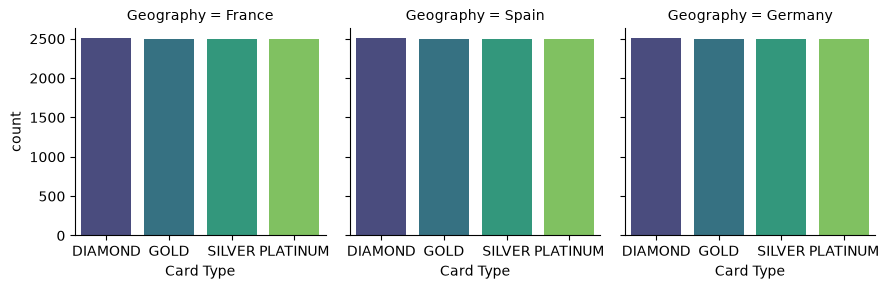

In [245]:
g=sns.FacetGrid(data,col='Geography')
g.map(sns.countplot,data=data,x='Card Type',order=['DIAMOND','GOLD','SILVER','PLATINUM'],hue='Card Type',palette='viridis')
plt.show()
